In [1]:
# Quick exploration of the KNMI surface solar irradiance forecast data.
# This could be used as a proxy for cloud cover - or as a target variable for cloud cover prediction.

# Data downloaded from https://dataplatform.knmi.nl/dataset/preview/surface-solar-irradiance-1-0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
data_folder = '/Users/michael/Research/Projects/CloudPredict/data/raw/'
ds = xr.open_dataset(data_folder + 'SEVIR_OPER_R__CPP_AODC_L2__20260413T163000_FCST_20260413T203000_0002_SUB_europapa.grb2')
ds

<xarray.Dataset> Size: 30MB
Dimensions:     (step: 16, latitude: 561, longitude: 841)
Coordinates:
  * step        (step) timedelta64[ns] 128B 00:15:00 00:30:00 ... 04:00:00
    valid_time  (step) datetime64[ns] 128B ...
  * latitude    (latitude) float64 4kB 35.0 35.05 35.1 35.15 ... 62.9 62.95 63.0
  * longitude   (longitude) float64 7kB -11.0 -10.95 -10.9 ... 30.9 30.95 31.0
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    ssrd        (step, latitude, longitude) float32 30MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T21:31 GRIB to CDM+CF via cfgrib-0.9.1...

/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


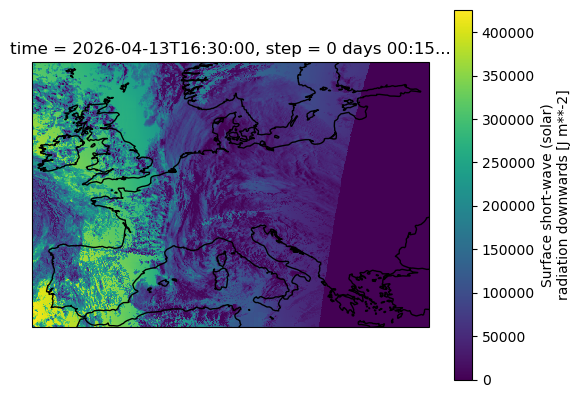

In [4]:
# Plot all data
ax = plt.axes(projection=ccrs.PlateCarree())
ds.isel(step=0).ssrd.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
plt.show()

/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/michael/miniconda3/envs/CloudPredict/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


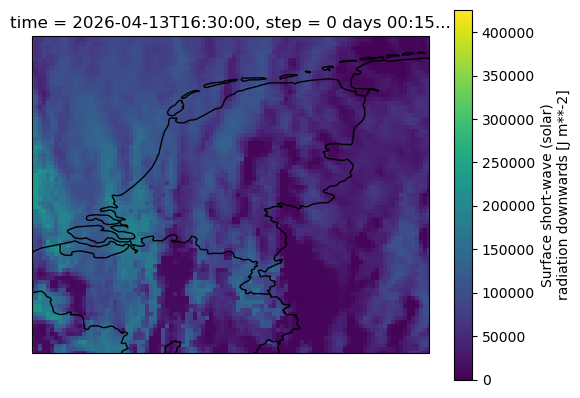

In [5]:
# Plot just the Netherlands
ax = plt.axes(projection=ccrs.PlateCarree())
ds.isel(step=0).ssrd.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_xlim(3,8)
ax.set_ylim(50,54)
plt.show()